In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [286]:
# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('merged_r8fin_trades.parquet')

In [265]:
len(trading_data)

5923559

In [264]:
len(trading_data['executionid'].unique())

5768753

## Method 1: Group by `recapid` and `instrument`

In [294]:
# Group trades by 'recapid' and extract unique instruments
multi_leg_instruments = trading_data.groupby('recapid')['instrument'].unique().reset_index(name='instruments')

# Count the number of unique instruments for each 'recapid' to determine the number of legs
multi_leg_counts = multi_leg_instruments.copy()
multi_leg_counts['instruments'] = multi_leg_counts['instruments'].apply(lambda x: x[0])

In [236]:
len(multi_leg_counts)

64305

### If `instruments` contains comma, it will be determined as Multi-Leg Trades.

In [295]:
contains_comma = multi_leg_counts['instruments'].str.contains(',')
multi_leg_counts['instruments'][multi_leg_counts['instruments'].str.contains(',')]

14          CBOT USU4,CBOT TYU4
152         CBOT FFU4,CBOT FFQ4
346       EUREX IKU4,EUREX RXU4
788         CBOT FFQ4,CBOT FFU4
792         CBOT FFU4,CBOT FFQ4
                  ...          
63819       CBOT FFZ4,CBOT FFX4
63827       CBOT FFX4,CBOT FFZ4
63829       CBOT FFX4,CBOT FFZ4
63875       CBOT FFZ4,CBOT FFX4
64117    UST 10_YEAR,UST 5_YEAR
Name: instruments, Length: 740, dtype: object

In [296]:
# Convert 'instruments' from a string to a list, splitting by commas if necessary
multi_leg_counts['instruments'] = [x.split(',') if ',' in x else [x] for x in multi_leg_counts['instruments']]
multi_leg_counts['num_legs'] = multi_leg_counts['instruments'].apply(len)


In [297]:
multi_leg_counts

,recapid,instruments,num_legs
0,540807.0,[UXYU4-XMU4 (Y)],1
1,540887.0,[OSE JBU4],1
2,541144.0,[SFE YMU4XMU4],1
3,541170.0,[SFE YMU4XMU4],1
4,541395.0,[SFE IRU5],1
...,...,...,...
64300,608700.0,[UST 5_YEAR],1
64301,608701.0,[CME SFR:BF Z4-H5-M5],1
64302,608702.0,[CT5-FVZ4],1
64303,608703.0,[SERFFF5-SERFFK5 (SER v FF Spread)],1


In [298]:
# Add columns for first, second, and third leg instruments in multi_leg_counts_filtered
multi_leg_counts['first_leg_instrument'] = multi_leg_counts['instruments'].apply(lambda x: x[0] if len(x) > 0 else None)
multi_leg_counts['second_leg_instrument'] = multi_leg_counts['instruments'].apply(lambda x: x[1] if len(x) > 1 else None)
multi_leg_counts['third_leg_instrument'] = multi_leg_counts['instruments'].apply(lambda x: x[2] if len(x) > 2 else None)

In [299]:
multi_leg_counts

,recapid,instruments,num_legs,first_leg_instrument,second_leg_instrument,third_leg_instrument
0,540807.0,[UXYU4-XMU4 (Y)],1,UXYU4-XMU4 (Y),None,None
1,540887.0,[OSE JBU4],1,OSE JBU4,None,None
2,541144.0,[SFE YMU4XMU4],1,SFE YMU4XMU4,None,None
3,541170.0,[SFE YMU4XMU4],1,SFE YMU4XMU4,None,None
4,541395.0,[SFE IRU5],1,SFE IRU5,None,None
...,...,...,...,...,...,...
64300,608700.0,[UST 5_YEAR],1,UST 5_YEAR,None,None
64301,608701.0,[CME SFR:BF Z4-H5-M5],1,CME SFR:BF Z4-H5-M5,None,None
64302,608702.0,[CT5-FVZ4],1,CT5-FVZ4,None,None
64303,608703.0,[SERFFF5-SERFFK5 (SER v FF Spread)],1,SERFFF5-SERFFK5 (SER v FF Spread),None,None


In [300]:
# Filter to keep only multi-leg trades
multi_leg_counts_filtered = multi_leg_counts[multi_leg_counts['num_legs'] > 1]

multi_leg_counts_filtered

,recapid,instruments,num_legs,first_leg_instrument,second_leg_instrument,third_leg_instrument
14,541988.0,"[CBOT USU4, CBOT TYU4]",2,CBOT USU4,CBOT TYU4,None
152,542130.0,"[CBOT FFU4, CBOT FFQ4]",2,CBOT FFU4,CBOT FFQ4,None
346,542340.0,"[EUREX IKU4, EUREX RXU4]",2,EUREX IKU4,EUREX RXU4,None
788,542802.0,"[CBOT FFQ4, CBOT FFU4]",2,CBOT FFQ4,CBOT FFU4,None
792,542806.0,"[CBOT FFU4, CBOT FFQ4]",2,CBOT FFU4,CBOT FFQ4,None
...,...,...,...,...,...,...
63819,608212.0,"[CBOT FFZ4, CBOT FFX4]",2,CBOT FFZ4,CBOT FFX4,None
63827,608220.0,"[CBOT FFX4, CBOT FFZ4]",2,CBOT FFX4,CBOT FFZ4,None
63829,608222.0,"[CBOT FFX4, CBOT FFZ4]",2,CBOT FFX4,CBOT FFZ4,None
63875,608269.0,"[CBOT FFZ4, CBOT FFX4]",2,CBOT FFZ4,CBOT FFX4,None


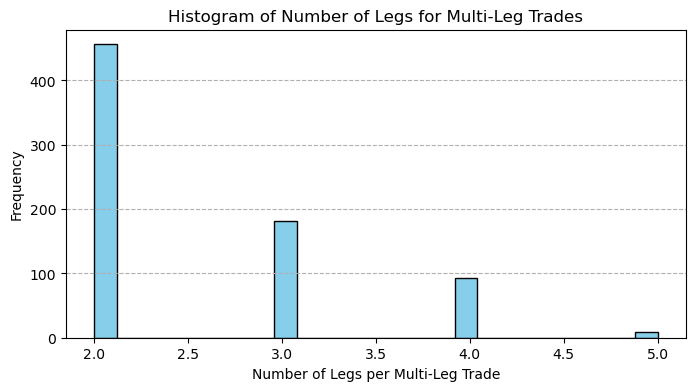

In [248]:
plt.figure(figsize=(8, 4))
plt.hist(multi_leg_counts_filtered['num_legs'], bins=25, color='skyblue', edgecolor='black')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Legs for Multi-Leg Trades')
plt.grid(axis='y', linestyle='--')
plt.show()

In [306]:
# Merge multi-leg information back to the original trading data
trading_data_with_legs = pd.merge(trading_data, multi_leg_counts_filtered[['recapid', 'num_legs', 'first_leg_instrument', 'second_leg_instrument', 'third_leg_instrument']], on='recapid', how='left')

# Add a column for market value in trading_data_with_legs using NumPy for efficiency
trading_data_with_legs['market_value'] = np.where(
    trading_data_with_legs['security_type'] == 'F',
    trading_data_with_legs['quantity'] * trading_data_with_legs['price'],
    trading_data_with_legs['quantity'] * 1e6
)

# Generate summary table for all trades (before filtering multi-leg trades)
summary_table_all = trading_data_with_legs.groupby('recapid').agg(
    cash_vs_future=('security_type', lambda x: 'Cash' if (x == 'C').all() else 'Future'),
    num_trades=('recapid', 'count'),
    market_value=('market_value', 'sum'),
    num_legs=('num_legs', 'max'),
    first_leg_instrument=('first_leg_instrument', 'first'),
    second_leg_instrument=('second_leg_instrument', 'first'),
    third_leg_instrument=('third_leg_instrument', 'first')
).reset_index()

# Calculate percentage columns for all trades
summary_table_all['% of All number of Trades'] = (summary_table_all['num_trades'] / summary_table_all['num_trades'].sum()) * 100
summary_table_all['% of Total Market Value of All Trades'] = (summary_table_all['market_value'] / summary_table_all['market_value'].sum()) * 100

# Filter to keep only multi-leg trades
summary_table = summary_table_all[summary_table_all['num_legs'] > 1]

In [307]:
summary_table

,recapid,cash_vs_future,num_trades,market_value,num_legs,first_leg_instrument,second_leg_instrument,third_leg_instrument,% of All number of Trades,% of Total Market Value of All Trades
14,541988.0,Future,2,1.754250e+04,2.0,CBOT USU4,CBOT TYU4,None,0.000034,7.032087e-07
152,542130.0,Future,2,9.472350e+02,2.0,CBOT FFU4,CBOT FFQ4,None,0.000034,3.797087e-08
346,542340.0,Future,155,2.833943e+04,2.0,EUREX IKU4,EUREX RXU4,None,0.002617,1.136014e-06
788,542802.0,Future,2,2.085170e+03,2.0,CBOT FFQ4,CBOT FFU4,None,0.000034,8.358613e-08
792,542806.0,Future,2,2.274685e+03,2.0,CBOT FFU4,CBOT FFQ4,None,0.000034,9.118303e-08
...,...,...,...,...,...,...,...,...,...,...
63819,608212.0,Future,2,4.100515e+03,2.0,CBOT FFZ4,CBOT FFX4,None,0.000034,1.643733e-07
63827,608220.0,Future,2,6.293675e+03,2.0,CBOT FFX4,CBOT FFZ4,None,0.000034,2.522883e-07
63829,608222.0,Future,4,6.293695e+03,2.0,CBOT FFX4,CBOT FFZ4,None,0.000068,2.522891e-07
63875,608269.0,Future,4,4.958623e+03,2.0,CBOT FFZ4,CBOT FFX4,None,0.000068,1.987714e-07


In [308]:
# Save the summary table to a CSV file
summary_table.to_csv('multi_leg_summary_table_instrument.csv', index=False)

# Method 2: Group by `recapid` and `orderid`

In [180]:
# Group trades by 'recapid' and extract unique orders
multi_leg_order = trading_data.groupby('recapid')['orderid'].unique().reset_index(name='orders')

# Count the number of unique instruments for each 'recapid' to determine the number of legs
multi_leg_counts = multi_leg_order.copy()
multi_leg_counts['num_legs'] = multi_leg_counts['orders'].apply(len)

In [181]:
multi_leg_counts

,recapid,orders,num_legs
0,540807.0,"[550658921, 550658894, 550658910, 550658929, 5...",11
1,540887.0,[550658935],1
2,541144.0,"[550658936, 550658937]",2
3,541170.0,[550658938],1
4,541395.0,[550658939],1
...,...,...,...
64300,608700.0,[7034971270],1
64301,608701.0,"[5018450960, 5018453077, 5018610615]",3
64302,608702.0,"[5018501551, 5018501552, 5018502274, 501850227...",521
64303,608703.0,"[5018452647, 5018452646]",2


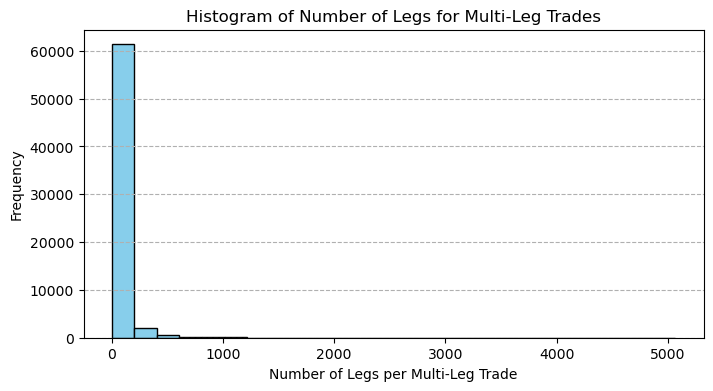

In [185]:
plt.figure(figsize=(8, 4))
plt.hist(multi_leg_counts['num_legs'], bins=25, color='skyblue', edgecolor='black')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Legs for Multi-Leg Trades')
plt.grid(axis='y', linestyle='--')
plt.show()

# Method 3: Group by `recapid` and `parentcorrelationorderid`

In [173]:
# Group trades by 'recapid' and 'parentcorrelationorderid' and extract unique instruments
multi_leg_instruments = trading_data.groupby(['recapid', 'parentcorrelationorderid'])['instrument'].apply(lambda x: list(x.unique())).reset_index(name='instruments')

# Count the number of unique 'parentcorrelationorderid' for each 'recapid' to determine the number of legs
multi_leg_counts = trading_data.groupby('recapid')['parentcorrelationorderid'].nunique().reset_index(name='num_legs')

# Filter to keep only multi-leg trades
multi_leg_counts_filtered = multi_leg_counts[multi_leg_counts['num_legs'] > 1]

# Merge multi-leg information back to the original trading data
trading_data_with_legs = pd.merge(trading_data, multi_leg_counts_filtered, on=['recapid'], how='inner')

# Merge instruments information back to the trading data
trading_data_with_legs = pd.merge(trading_data_with_legs, multi_leg_instruments, on=['recapid', 'parentcorrelationorderid'], how='left')


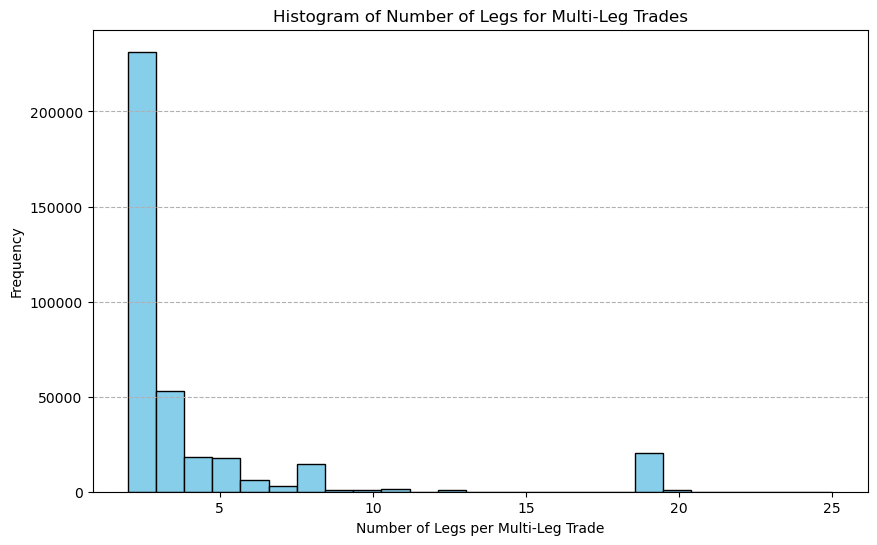

In [174]:
# Frequency histogram for the number of legs in all multi-leg trades
plt.figure(figsize=(10, 6))
plt.hist(trading_data_with_legs['num_legs'], bins=25, color='skyblue', edgecolor='black')
plt.xlabel('Number of Legs per Multi-Leg Trade')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Legs for Multi-Leg Trades')
plt.grid(axis='y', linestyle='--')
plt.show()

In [152]:
leg_counts_table = trading_data_with_legs['num_legs'].value_counts().reset_index()
leg_counts_table.columns = ['Number of Legs', 'Count']
leg_counts_table = leg_counts_table.sort_values(by='Number of Legs').reset_index(drop=True)

# View the leg counts table
print(leg_counts_table)

    Number of Legs   Count
0                2  231418
1                3   52822
2                4   18396
3                5   17964
4                6    6397
5                7    3011
6                8   14485
7                9     667
8               10     856
9               11    1506
10              12      59
11              13     782
12              14      23
13              17      31
14              19   20463
15              20     750
16              25      46


In [131]:
# Check whether each leg have a unique instrument
grouped_instruments = trading_data.groupby(['recapid', 'parentcorrelationorderid'])['instrument'].nunique().reset_index(name='unique_instruments')
grouped_instruments['unique_instruments'].unique()

array([1])

In [150]:
# Generate summary table for multi-leg trades
summary_table = trading_data_with_legs.groupby('recapid').agg(
    cash_vs_future=('security_type', lambda x: 'Cash' if (x == 'C').all() else 'Future'),
    first_leg_instrument=('instruments', lambda x: list(x)[0][0] if len(x) > 0 else None),
    second_leg_instrument=('instruments', lambda x: list(x)[1][0] if len(x) > 1 else None),
    third_leg_instrument=('instrument', lambda x: x.iloc[2] if len(x) > 2 else None),
    num_trades=('recapid', 'count'),
    market_value=('quantity', 'sum'),
    num_legs=('num_legs', 'max')
).reset_index()

# Calculate percentage columns
summary_table['% of All number of Trades'] = (summary_table['num_trades'] / summary_table['num_trades'].sum()) * 100
summary_table['% of Total Market Value of All Trades'] = (summary_table['market_value'] / summary_table['market_value'].sum()) * 100
# Ensure third_leg_instrument is set to None for trades with only two legs
summary_table.loc[summary_table['num_legs'] == 2, 'third_leg_instrument'] = None

In [151]:
summary_table

,recapid,cash_vs_future,first_leg_instrument,second_leg_instrument,third_leg_instrument,num_trades,market_value,num_legs,% of All number of Trades,% of Total Market Value of All Trades
0,541144.0,Future,SFE YMU4XMU4,SFE YMU4XMU4,None,18,600.0,2,0.004869,0.013673
1,541988.0,Future,"CBOT USU4,CBOT TYU4","CBOT USU4,CBOT TYU4",None,2,150.0,2,0.000541,0.003418
2,541996.0,Future,CBOT UXYU4,CBOT UXYU4,None,2,40.0,2,0.000541,0.000912
3,542039.0,Cash,CT5-CT30 (Y),CT5-CT30 (Y),None,28,42.0,2,0.007574,0.000957
4,542050.0,Future,CT2-TUU4,CT2-TUU4,CT2-TUU4,102,252.0,5,0.027592,0.005743
...,...,...,...,...,...,...,...,...,...,...
2432,608583.0,Cash,UST 7_YEAR,UST 7_YEAR,UST 7_YEAR,21,58.0,4,0.005681,0.001322
2433,608585.0,Cash,UST 10_YEAR,UST 10_YEAR,UST 10_YEAR,44,200.0,4,0.011902,0.004558
2434,608595.0,Future,DUZ4 ESTR (ZDUCKY),DUZ4 ESTR (ZDUCKY),None,52,96.0,2,0.014066,0.002188
2435,608641.0,Future,CT7-TYZ4 0.91,CT7-TYZ4 0.91,CT7-TYZ4 0.91,21,111.0,4,0.005681,0.002529


In [186]:
# Save the summary table to a CSV file
summary_table.to_csv('multi_leg_trades_summary_table.csv', index=False)